# Graph statistics

In [1]:
# DATASET = "Imprisonment-IT"
DATASET = "IMDB"
DATASET_PATH = f"../data/datasets/{DATASET}/train/interim"

In [2]:
import networkx as nx


def print_graph_statistics_multidigraph(G: nx.MultiDiGraph) -> None:
    """
    Print graph-level statistics for a given NetworkX MultiDiGraph in a single line format.
    Handles directed multigraphs appropriately.

    Parameters:
    - G (nx.MultiDiGraph): A NetworkX MultiDiGraph object

    Returns:
    - None
    """
    # Calculate graph statistics
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
    density = nx.density(G)

    # Convert to a simple directed graph for certain metrics
    simple_graph = nx.DiGraph(G)

    # Check connectivity and calculate diameter and average path length if applicable
    if nx.is_weakly_connected(simple_graph):
        try:
            diameter = nx.diameter(simple_graph)
            avg_path_length = nx.average_shortest_path_length(simple_graph)
        except nx.NetworkXError:
            diameter = "N/A"
            avg_path_length = "N/A"
    else:
        diameter = "N/A"
        avg_path_length = "N/A"

    # Average clustering coefficient
    avg_clustering = nx.average_clustering(simple_graph.to_undirected())

    # Print statistics in a single line
    # print(f"Nodes: {num_nodes}, Edges: {num_edges}, Avg Degree: {avg_degree:.2f}, "
    #       f"Density: {density:.4f}, Diameter: {diameter}, "
    #       f"Avg Path Length: {avg_path_length}, "
    #       f"Avg Clustering Coefficient: {avg_clustering:.4f}")

    return num_nodes, num_edges, avg_degree, density, avg_clustering


In [4]:
import tqdm
import torch
from pathlib import Path

stored_graph_paths = Path(DATASET_PATH).glob("*.pt")
stored_graph_paths = list(stored_graph_paths)

max_num_nodes = 0
max_num_edges = 0
doc_max_nodes = None
label_max_nodes = None

num_nodes_global = []
num_edges_global = []
for graph_data_path in tqdm.tqdm(stored_graph_paths, desc="Analysing graphs"):
    doc_name, label, graph_nx = torch.load(graph_data_path)

    num_nodes, num_edges, avg_degree, density, avg_clustering = print_graph_statistics_multidigraph(graph_nx)

    if num_nodes > max_num_nodes:
        max_num_nodes = num_nodes
        doc_max_nodes = doc_name
        label_max_nodes = label
        max_num_edges = num_edges
    num_nodes_global.append(num_nodes)
    num_edges_global.append(num_edges)



print(f"Doc: {doc_max_nodes}, Label: {label_max_nodes}, Max Nodes: {max_num_nodes}")



Analysing graphs:   0%|          | 0/40000 [00:00<?, ?it/s]/tmp/ipykernel_17561/3234876737.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  doc_name, label, graph_nx = t

Doc: 8362.txt, Label: positive, Max Nodes: 817


(array([8.5210e+03, 2.0978e+04, 6.4160e+03, 2.5550e+03, 1.0440e+03,
        4.2500e+02, 5.2000e+01, 4.0000e+00, 3.0000e+00, 2.0000e+00]),
 array([  4. ,  85.3, 166.6, 247.9, 329.2, 410.5, 491.8, 573.1, 654.4,
        735.7, 817. ]),
 <BarContainer object of 10 artists>)

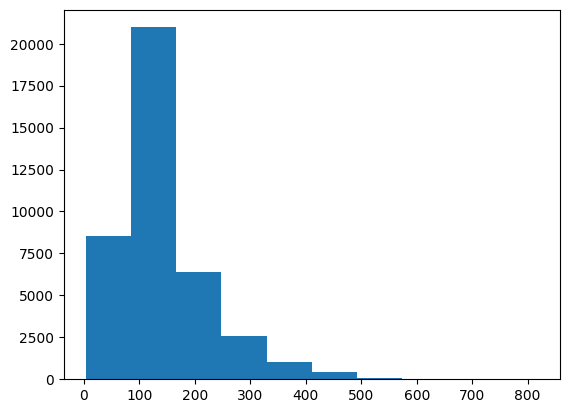

In [5]:
from matplotlib import pyplot as plt

plt.hist(num_nodes_global)

(array([2.8224e+04, 8.6480e+03, 2.2030e+03, 8.2300e+02, 8.8000e+01,
        6.0000e+00, 4.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00]),
 array([   7. ,  495.4,  983.8, 1472.2, 1960.6, 2449. , 2937.4, 3425.8,
        3914.2, 4402.6, 4891. ]),
 <BarContainer object of 10 artists>)

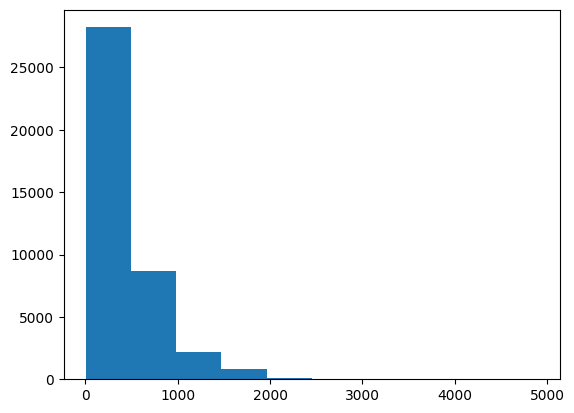

In [6]:
plt.hist(num_edges_global)